
# NBA Shot Data — 2024–25 Season (Full, Schema‑Adaptive)

This notebook normalizes the 2024–25 shot schema (e.g., `xLegacy`, `yLegacy`, `shotDistance`, `shotResult`, `SHOT_CLOCK_APPROX`, `teamTricode`, `playerName`, `gameId`) to a consistent set of fields and produces the following visuals:

- Overview metrics
- Shot selection (2 vs 3), distance distribution
- Court shot charts (positions + make vs miss)
- Player **FG%** leaders (min 200 attempts)
- **Hexbin by location colored with `eFG%`**
- **FG% heatmap** by *(distance × shot clock)*
- Team shot profiles *(3PA rate vs FG%)*
- **Team 3PA rate vs Points per Game** *(FG points only)*
- **Top 10 points‑per‑game players** *(FG points only)*
- **Player eFG% (x) vs Attempts (y), labeled, min 1000 attempts**
- **Player "Bad Shot" % (x) vs Attempts (y), labeled, min 800 attempts)**

> **Notes**
> - Uses only `matplotlib` (no seaborn), single‑figure charts.
> - PPG here is **field‑goal points only** (no FTs in this file).
> - The notebook is defensive: if a column is missing, the affected plot is skipped with a message.


## 0) Load & Normalize Schema

In [1]:
# === 0) Setup & Load (schema-adaptive) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your 2024–25 CSV (change if needed)
FILE_PATH = "enriched_data/nbastatsv3_2024_enriched_shots.csv"

shots_raw = pd.read_csv(FILE_PATH)
print(f"Loaded {len(shots_raw):,} rows, {shots_raw.shape[1]} columns")
print("Columns:", list(shots_raw.columns))

shots = shots_raw.copy()

# ---- Normalize to a consistent schema used in subsequent cells ----
# Player name (long) and display/initialed name
if 'name' not in shots.columns and 'playerName' in shots.columns:
    shots['name'] = shots['playerName']

# Team display name
if 'team_name' not in shots.columns:
    if 'teamTricode' in shots.columns:
        shots['team_name'] = shots['teamTricode']
    elif 'teamName' in shots.columns:
        shots['team_name'] = shots['teamName']

# Game id
if 'espn_game_id' not in shots.columns and 'gameId' in shots.columns:
    shots['espn_game_id'] = shots['gameId']

# Coordinates
if 'x' not in shots.columns and 'xLegacy' in shots.columns:
    shots['x'] = shots['xLegacy']
if 'y' not in shots.columns and 'yLegacy' in shots.columns:
    shots['y'] = shots['yLegacy']

# Distance
if 'shot_distance' not in shots.columns and 'shotDistance' in shots.columns:
    shots['shot_distance'] = shots['shotDistance']

# Canonical shot clock from SHOT_CLOCK_APPROX
if 'SHOT_CLOCK_APPROX' in shots.columns:
    shots['shot_clock'] = pd.to_numeric(shots['SHOT_CLOCK_APPROX'], errors='coerce')
elif 'shot_clock' in shots.columns:
    shots['shot_clock'] = pd.to_numeric(shots['shot_clock'], errors='coerce')

# Made/miss
if 'shot_made_flag' not in shots.columns and 'shotResult' in shots.columns:
    shots['shot_made_flag'] = (shots['shotResult'].astype(str).str.lower() == 'made').astype(int)

# Ensure numbers
for col in ['x','y','shot_distance','shot_clock','shotValue','contest_score']:
    if col in shots.columns:
        shots[col] = pd.to_numeric(shots[col], errors='coerce')

# Quick preview of key columns (only showing those that exist)
preview_cols = ['personId','playerNameI','name','team_name','espn_game_id','x','y',
                'shot_distance','shot_clock','shotValue','shot_made_flag',
                'contest_score','contest_label','SHOT_CLOCK_SOURCE']
shots[[c for c in preview_cols if c in shots.columns]].head(8)


Loaded 219,528 rows, 30 columns
Columns: ['actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId', 'gameId', 'ABS_TIME', 'SHOT_CLOCK_APPROX', 'SHOT_CLOCK_SOURCE', 'contest_score', 'contest_label', 'contest_reasons']


,personId,playerNameI,name,team_name,espn_game_id,x,y,shot_distance,shot_clock,shotValue,shot_made_flag,contest_score,contest_label,SHOT_CLOCK_SOURCE
0,1642258,Z. Risacher,Risacher,ATL,22400001,-168,205,27,7.0,3,0,-2,likely_open,period_start(24)
1,1642258,Z. Risacher,Risacher,ATL,22400001,10,13,2,12.0,2,1,1,borderline,made_fg(24)
2,1642258,Z. Risacher,Risacher,ATL,22400001,53,111,12,3.0,2,0,4,likely_contested,def_reb(24)
3,1642258,Z. Risacher,Risacher,ATL,22400001,-10,17,2,13.0,2,0,3,likely_contested,off_reb(14)
4,1642258,Z. Risacher,Risacher,ATL,22400001,-10,1,1,14.0,2,0,3,likely_contested,off_reb(14)
5,1642258,Z. Risacher,Risacher,ATL,22400001,0,0,0,12.0,2,0,3,likely_contested,off_reb(14)
6,1642258,Z. Risacher,Risacher,ATL,22400001,-21,15,3,7.0,2,1,1,borderline,def_reb(24)
7,1642258,Z. Risacher,Risacher,ATL,22400001,163,185,25,13.0,3,0,-1,likely_open,def_reb(24)


## 1) Quick Schema & Hygiene

In [2]:
# === 1) Quick Schema & Hygiene ===
print(shots.dtypes)

missing = shots.isna().mean().sort_values(ascending=False)
print("\nMissing ratio by column (top 12):")
print(missing.head(12))

expected = ['personId','playerNameI','name','team_name','espn_game_id','x','y',
            'shot_made_flag','shotValue','shot_distance','shot_clock',
            'contest_score','contest_label','SHOT_CLOCK_SOURCE']
missing_cols = [c for c in expected if c not in shots.columns]
print("\nMissing expected (plots may skip):", missing_cols)


actionNumber           int64
clock                 object
period                 int64
teamId                 int64
teamTricode           object
personId               int64
playerName            object
playerNameI           object
xLegacy                int64
yLegacy                int64
shotDistance           int64
shotResult            object
isFieldGoal            int64
scoreHome            float64
scoreAway            float64
pointsTotal            int64
location              object
description           object
actionType            object
subType               object
videoAvailable         int64
shotValue              int64
actionId               int64
gameId                 int64
ABS_TIME               int64
SHOT_CLOCK_APPROX    float64
SHOT_CLOCK_SOURCE     object
contest_score          int64
contest_label         object
contest_reasons       object
name                  object
team_name             object
espn_game_id           int64
x                      int64
y             

## 2) Overview KPIs

In [3]:
# === 2) Overview KPIs ===
total_shots = len(shots)
fg_pct = shots['shot_made_flag'].mean() if 'shot_made_flag' in shots else float('nan')

print(f"Total shots: {total_shots:,}")
print(f"Overall FG%: {fg_pct:.2%}" if pd.notna(fg_pct) else "Overall FG%: N/A")


Total shots: 219,528
Overall FG%: 46.72%


## 3) Shot Selection — 2PA vs 3PA

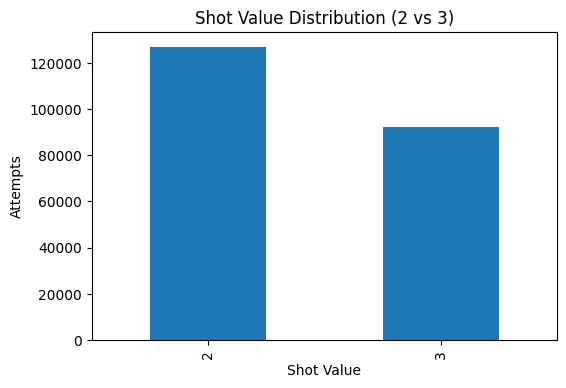

In [4]:
# === 3) Shot Selection — 2PA vs 3PA ===
if 'shotValue' in shots.columns:
    fig = plt.figure(figsize=(6,4))
    shots['shotValue'].value_counts().sort_index().plot(kind='bar')
    plt.title("Shot Value Distribution (2 vs 3)")
    plt.xlabel("Shot Value")
    plt.ylabel("Attempts")
    plt.show()
else:
    print("No 'shotValue' column.")


## 4) Shot Distance Distribution

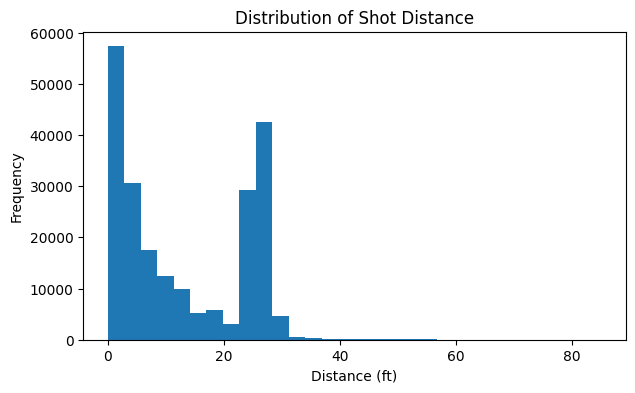

In [5]:
# === 4) Shot Distance Distribution ===
if 'shot_distance' in shots.columns:
    fig = plt.figure(figsize=(7,4))
    plt.hist(shots['shot_distance'].dropna(), bins=30)
    plt.title("Distribution of Shot Distance")
    plt.xlabel("Distance (ft)")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No 'shot_distance' column (expected from 'shotDistance').")


## 5) Court Shot Charts

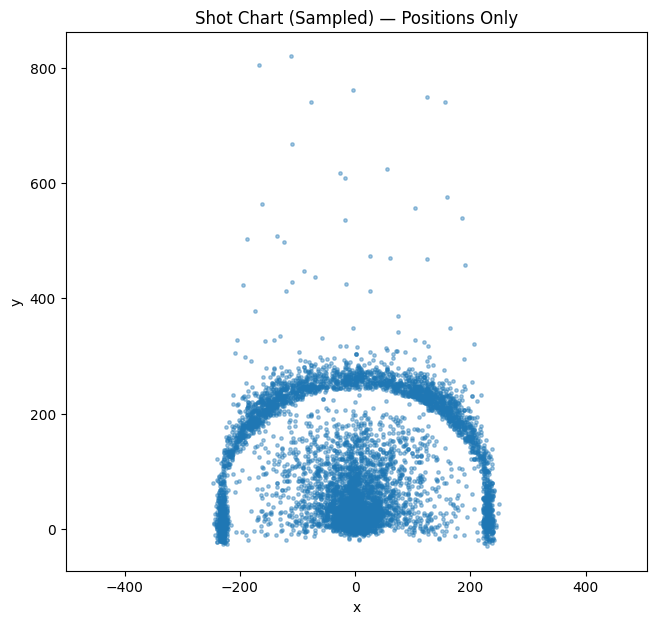

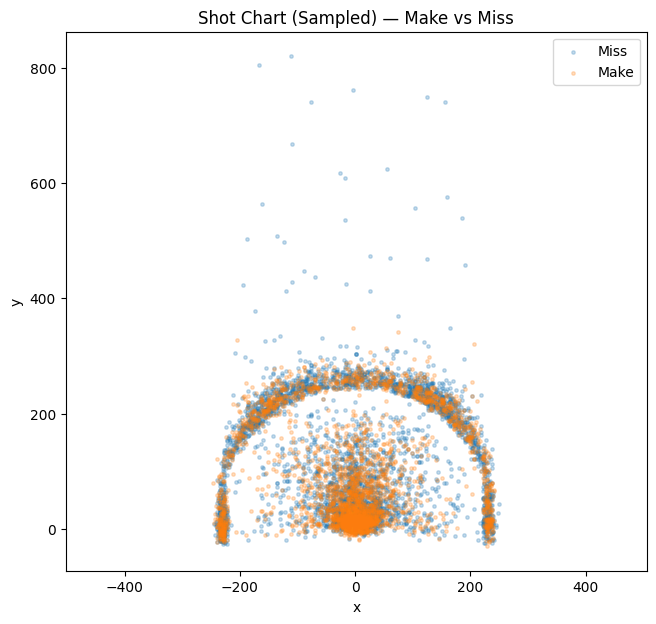

In [6]:
# === 5) Court Shot Charts ===
need = {'x','y','shot_made_flag'}
if need.issubset(shots.columns):
    sample_n = min(7500, len(shots))
    sampled = shots.sample(sample_n, random_state=42)[['x','y','shot_made_flag']].dropna()

    # Positions only
    fig = plt.figure(figsize=(7.5,7))
    plt.scatter(sampled['x'], sampled['y'], s=6, alpha=0.4)
    plt.title("Shot Chart (Sampled) — Positions Only")
    plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
    plt.show()

    # Make vs Miss
    made = sampled[sampled['shot_made_flag'] == 1]
    miss = sampled[sampled['shot_made_flag'] == 0]
    fig = plt.figure(figsize=(7.5,7))
    plt.scatter(miss['x'], miss['y'], s=6, alpha=0.25, label="Miss")
    plt.scatter(made['x'], made['y'], s=6, alpha=0.25, label="Make")
    plt.title("Shot Chart (Sampled) — Make vs Miss")
    plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal'); plt.legend()
    plt.show()
else:
    print("Need x, y, shot_made_flag; skipping chart.")


## 6) Player FG% Leaders (min 200 attempts)

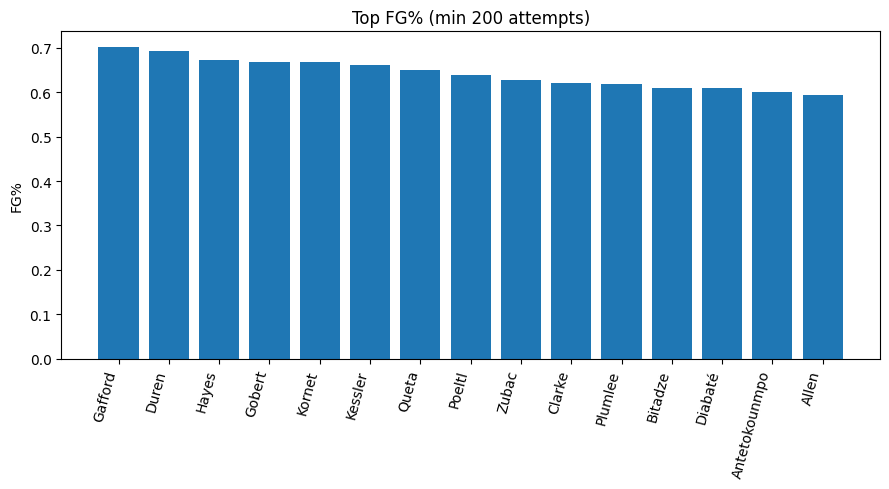

In [7]:
# === 6) Player FG% Leaders (min 200 attempts) ===
if {'name','shot_made_flag'}.issubset(shots.columns):
    stats = (shots.groupby('name')
                   .agg(attempts=('shot_made_flag','size'),
                        fg_pct=('shot_made_flag','mean'))
                   .reset_index())
    leaders = stats.query('attempts >= 200').sort_values('fg_pct', ascending=False).head(15)

    fig = plt.figure(figsize=(9,5))
    plt.bar(leaders['name'], leaders['fg_pct'])
    plt.title("Top FG% (min 200 attempts)")
    plt.ylabel("FG%")
    plt.xticks(rotation=75, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Missing 'name' or 'shot_made_flag'.")


## 7) Hexbin — eFG% by Location (min 20 attempts per hex)

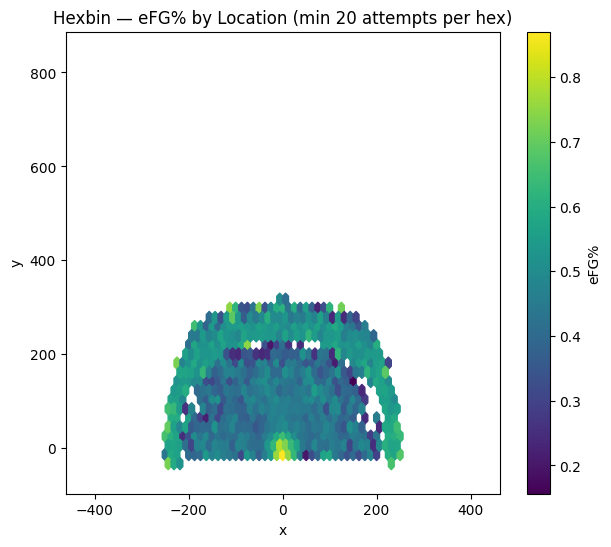

In [8]:
# === 7) Hexbin — eFG% by Location (min 20 attempts per hex) ===
need = {'x','y','shot_made_flag','shotValue'}
if need.issubset(shots.columns):
    sh = shots.copy()
    sh['efg_contrib'] = sh['shot_made_flag'] * (1 + 0.5*(sh['shotValue'] == 3))

    fig = plt.figure(figsize=(7,6))
    hb = plt.hexbin(sh['x'].values, sh['y'].values,
                    C=sh['efg_contrib'].values.astype(float),
                    gridsize=40, reduce_C_function=np.mean, mincnt=20)
    plt.title("Hexbin — eFG% by Location (min 20 attempts per hex)")
    plt.xlabel("x"); plt.ylabel("y")
    cb = plt.colorbar(hb); cb.set_label("eFG%")
    plt.axis('equal')
    plt.show()
else:
    print("Need x, y, shot_made_flag, shotValue.")


## 8) FG% Heatmap — Distance × Shot Clock

In [9]:
# Diagnostic: distribution of SHOT_CLOCK_APPROX by make/miss
assert 'shot_clock' in shots.columns and 'shot_made_flag' in shots.columns, "Run the load/normalize cell first."

bins = [0, 0.25, 0.5, 1, 2, 5, 10, 15, 20, 24.1]
tbl = (
    shots.assign(sc_bin=pd.cut(shots['shot_clock'], bins=bins, include_lowest=True))
         .groupby(['sc_bin'], dropna=False)
         .agg(attempts=('shot_made_flag','size'),
              makes=('shot_made_flag','sum'),
              fg_pct=('shot_made_flag','mean'))
)
tbl['makes_share'] = tbl['makes'] / tbl['attempts'].replace(0, np.nan)
print(tbl)

# Shot clock calculation could include many errors.


                attempts  makes    fg_pct  makes_share
sc_bin                                                
(-0.001, 0.25]      3641   1437  0.394672     0.394672
(0.25, 0.5]            0      0       NaN          NaN
(0.5, 1.0]          4748   1912  0.402696     0.402696
(1.0, 2.0]          5661   2330  0.411588     0.411588
(2.0, 5.0]         23633  10348  0.437862     0.437862
(5.0, 10.0]        58698  26816  0.456847     0.456847
(10.0, 15.0]       66837  31977  0.478433     0.478433
(15.0, 20.0]       40819  20204  0.494966     0.494966
(20.0, 24.1]        9082   5005  0.551090     0.551090
NaN                 6409   2537  0.395850     0.395850


/var/folders/02/8qskm_yj6gx6xyj73fgxk36h0000gp/T/ipykernel_84911/1885538597.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['sc_bin'], dropna=False)


=== CREATING FG% HEATMAP ===

Total shots: 219,528
Overall FG%: 46.7%

Creating heatmap with 219,528 shots

FG% by Distance and Contest Level:
contest_category      Open  Borderline  Contested
dist_bin                                         
(-0.001, 3.0]     0.390070    0.760456   0.637794
(3.0, 8.0]        0.444172    0.531133   0.437386
(8.0, 16.0]       0.468373    0.460811   0.440006
(16.0, 23.0]      0.424396    0.304348   0.391051
(23.0, 30.0]      0.369166    0.333333   0.337311

Sample sizes:
contest_category   Open  Borderline  Contested
dist_bin                                      
(-0.001, 3.0]     13877       15876      41377
(3.0, 8.0]         1630        4272      28412
(8.0, 16.0]        1328        1480      24686
(16.0, 23.0]       1779          69       7375
(23.0, 30.0]      51378         105      23714



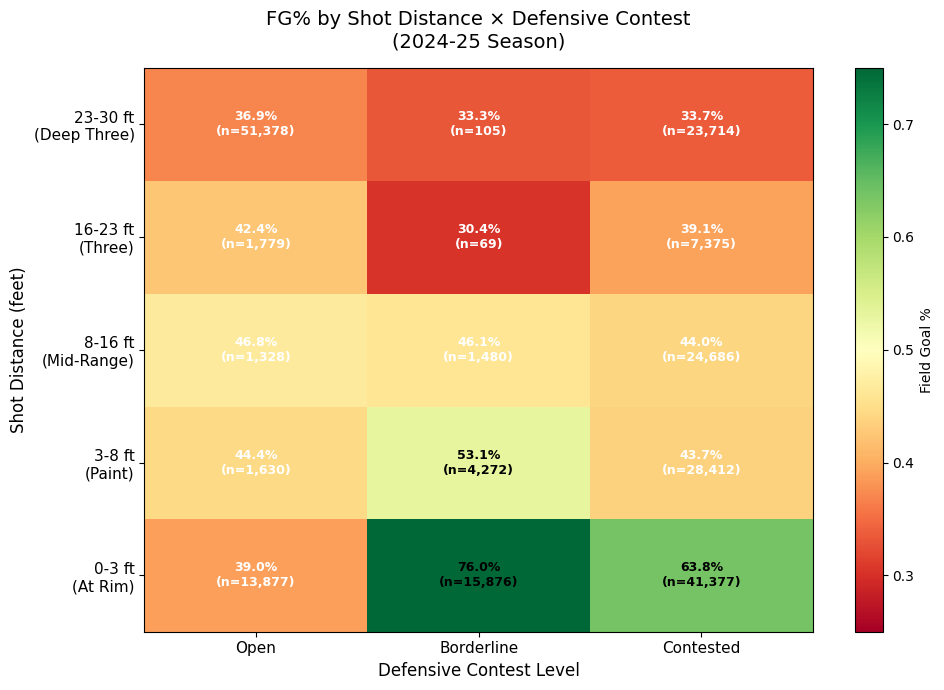

In [10]:
# === 8) FG% Heatmap — Distance × Contest Level ===
# NOTE: Shot clock data has quality issues, so we'll use contest level instead

print("=== CREATING FG% HEATMAP ===\n")
print(f"Total shots: {len(shots):,}")
print(f"Overall FG%: {shots['shot_made_flag'].mean():.1%}\n")

# Check if we have the required columns
if {'shot_made_flag','shot_distance','contest_label'}.issubset(shots.columns):
    # Create clean dataset
    shots_heat = shots[(shots['shot_distance'] >= 0)].copy()
    
    print(f"Creating heatmap with {len(shots_heat):,} shots\n")
    
    # Define distance bins
    dist_bins = [0, 3, 8, 16, 23, 30]
    shots_heat['dist_bin'] = pd.cut(shots_heat['shot_distance'], bins=dist_bins, include_lowest=True)
    
    # Map contest labels to simpler categories
    def simplify_contest(label):
        if pd.isna(label):
            return 'Unknown'
        label_lower = str(label).lower()
        if 'open' in label_lower:
            return 'Open'
        elif 'contested' in label_lower:
            return 'Contested'
        else:
            return 'Borderline'
    
    shots_heat['contest_category'] = shots_heat['contest_label'].apply(simplify_contest)
    
    # Create pivot tables
    mean_tbl = shots_heat.pivot_table(
        values='shot_made_flag',
        index='dist_bin',
        columns='contest_category',
        aggfunc='mean',
        observed=True
    )
    cnt_tbl = shots_heat.pivot_table(
        values='shot_made_flag',
        index='dist_bin',
        columns='contest_category',
        aggfunc='size',
        observed=True
    )
    
    # Reorder columns for better display
    col_order = [c for c in ['Open', 'Borderline', 'Contested', 'Unknown'] if c in mean_tbl.columns]
    mean_tbl = mean_tbl[col_order]
    cnt_tbl = cnt_tbl[col_order]
    
    print("FG% by Distance and Contest Level:")
    print(mean_tbl)
    print("\nSample sizes:")
    print(cnt_tbl)
    print()
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(mean_tbl.values, aspect='auto', origin='lower', 
                   vmin=0.25, vmax=0.75, cmap='RdYlGn')
    
    ax.set_title("FG% by Shot Distance × Defensive Contest\n(2024-25 Season)", 
                 fontsize=14, pad=15)
    ax.set_xlabel("Defensive Contest Level", fontsize=12)
    ax.set_ylabel("Shot Distance (feet)", fontsize=12)
    
    # Labels
    dist_labels = ['0-3 ft\n(At Rim)', '3-8 ft\n(Paint)', '8-16 ft\n(Mid-Range)', 
                   '16-23 ft\n(Three)', '23-30 ft\n(Deep Three)']
    
    ax.set_xticks(np.arange(len(mean_tbl.columns)))
    ax.set_xticklabels(mean_tbl.columns, fontsize=11)
    ax.set_yticks(np.arange(len(mean_tbl.index)))
    ax.set_yticklabels(dist_labels, fontsize=11)
    
    # Colorbar
    cb = plt.colorbar(im, ax=ax, label="Field Goal %")
    cb.ax.tick_params(labelsize=10)
    
    # Add text annotations
    for r in range(mean_tbl.shape[0]):
        for c in range(mean_tbl.shape[1]):
            fg_val = mean_tbl.iloc[r, c]
            cnt = cnt_tbl.iloc[r, c]
            if pd.notna(fg_val) and pd.notna(cnt):
                text_color = 'white' if fg_val < 0.5 else 'black'
                ax.text(c, r, f"{fg_val:.1%}\n(n={int(cnt):,})",
                       ha='center', va='center', fontsize=9,
                       color=text_color, weight='bold')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Missing required columns. Trying FG% by distance only...")
    
    # Fallback: just show FG% by distance
    if {'shot_made_flag','shot_distance'}.issubset(shots.columns):
        dist_bins = [0, 3, 5, 8, 10, 14, 16, 20, 23, 26, 30]
        shots_clean = shots[shots['shot_distance'] >= 0].copy()
        shots_clean['dist_bin'] = pd.cut(shots_clean['shot_distance'], bins=dist_bins, include_lowest=True)
        
        dist_stats = shots_clean.groupby('dist_bin', observed=True).agg(
            attempts=('shot_made_flag', 'size'),
            makes=('shot_made_flag', 'sum'),
            fg_pct=('shot_made_flag', 'mean')
        ).reset_index()
        
        fig, ax = plt.subplots(figsize=(12, 6))
        bars = ax.bar(range(len(dist_stats)), dist_stats['fg_pct'], color='steelblue', alpha=0.7)
        ax.set_xlabel('Shot Distance (feet)', fontsize=12)
        ax.set_ylabel('Field Goal %', fontsize=12)
        ax.set_title('FG% by Shot Distance (2024-25 Season)', fontsize=14)
        ax.set_xticks(range(len(dist_stats)))
        ax.set_xticklabels([str(x) for x in dist_stats['dist_bin']], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        # Add values on bars
        for i, (idx, row) in enumerate(dist_stats.iterrows()):
            ax.text(i, row['fg_pct'] + 0.01, f"{row['fg_pct']:.1%}\n(n={int(row['attempts']):,})",
                   ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        print("\nFG% by Distance:")
        print(dist_stats)

In [11]:
# Compare early vs late clock inside the shortest distance bin
dist_bin = pd.Interval(0,5, closed='right')
clk_early = pd.Interval(0,5, closed='right')
clk_late  = pd.Interval(20,24.1, closed='right')

dist_cuts  = pd.cut(shots_heat['shot_distance'], [0,5,10,15,20,25,30], include_lowest=True)
clock_cuts = pd.cut(shots_heat['shot_clock'],    [0,5,10,15,20,24.1],   include_lowest=True)

check = (
    shots_heat.assign(dist_bin=dist_cuts, clk_bin=clock_cuts)
              .query('dist_bin == @dist_bin and clk_bin in [@clk_early, @clk_late]')
              .groupby('clk_bin')
              .agg(attempts=('shot_made_flag','size'),
                   fg_pct=('shot_made_flag','mean'))
)
print(check)


               attempts  fg_pct
clk_bin                        
(-0.001, 5.0]         0     NaN
(5.0, 10.0]           0     NaN
(10.0, 15.0]          0     NaN
(15.0, 20.0]          0     NaN
(20.0, 24.1]          0     NaN


/var/folders/02/8qskm_yj6gx6xyj73fgxk36h0000gp/T/ipykernel_84911/2026093252.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('clk_bin')


## 9) Team Shot Profiles — 3PA Rate vs FG% (bubble = avg distance)

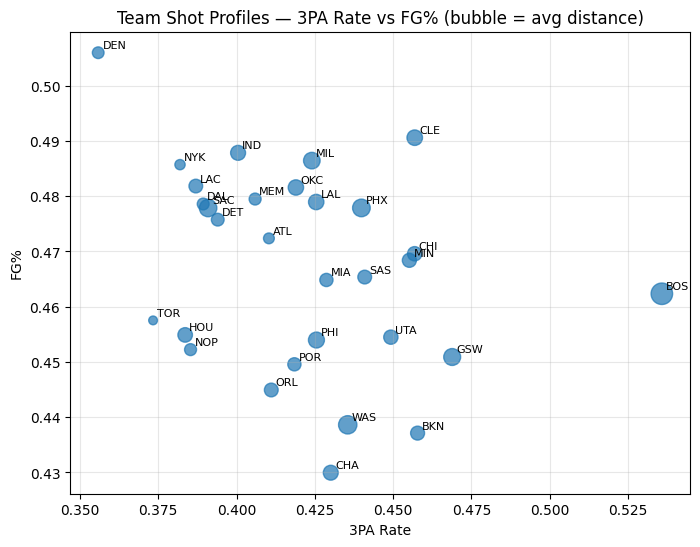

In [12]:
# === 9) Team Shot Profiles — 3PA Rate vs FG% (bubble = avg distance) ===
need = {'team_name','shotValue','shot_made_flag','shot_distance'}
if need.issubset(shots.columns):
    team = (shots.groupby('team_name')
                  .agg(avg_dist=('shot_distance','mean'),
                       three_rate=('shotValue', lambda x: np.mean(x == 3)),
                       fg_pct=('shot_made_flag','mean'))
                  .reset_index())

    fig = plt.figure(figsize=(8,6))
    sizes = 200 * (team['avg_dist'] - team['avg_dist'].min()) / (team['avg_dist'].max() - team['avg_dist'].min() + 1e-9) + 40
    plt.scatter(team['three_rate'], team['fg_pct'], s=sizes, alpha=0.7)
    for _, r in team.iterrows():
        plt.annotate(r['team_name'], (r['three_rate'], r['fg_pct']), xytext=(3,3), textcoords='offset points', fontsize=8)
    plt.title("Team Shot Profiles — 3PA Rate vs FG% (bubble = avg distance)")
    plt.xlabel("3PA Rate"); plt.ylabel("FG%")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Missing columns for team profile.")


## 10) Helper — Compute Field‑Goal Points

In [13]:
# === 10) Helper — Compute Field-Goal Points ===
if {'shot_made_flag','shotValue'}.issubset(shots.columns):
    shots['fg_points'] = shots['shot_made_flag'] * shots['shotValue']
else:
    print("Missing 'shot_made_flag' or 'shotValue'.")


## 11) Team 3PA Rate vs Points per Game (FG‑only)

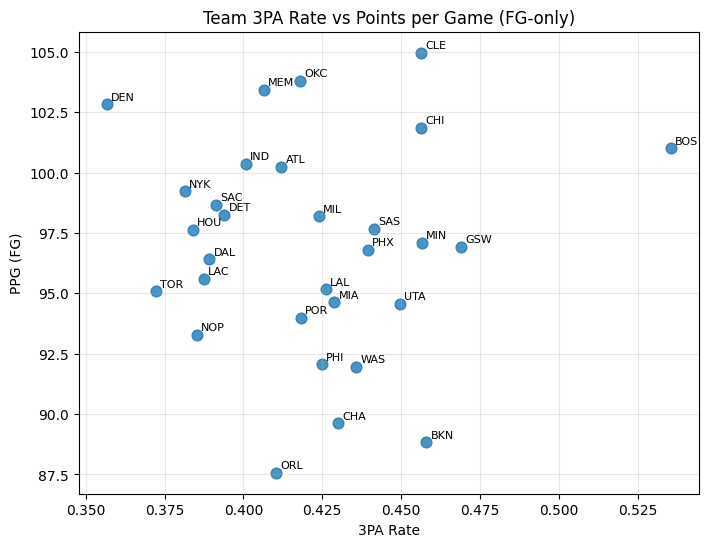

In [14]:
# === 11) Team 3PA Rate vs Points per Game (FG-only) ===
need = {'team_name','shotValue','shot_made_flag','espn_game_id','fg_points'}
if need.issubset(shots.columns):
    tg = (shots.groupby(['team_name','espn_game_id'])
                .agg(fga=('shot_made_flag','size'),
                     three_att=('shotValue', lambda x: np.sum(x == 3)),
                     fg_points=('fg_points','sum'))
                .reset_index())
    tg['three_rate'] = tg['three_att'] / tg['fga']

    team_ppg = tg.groupby('team_name').agg(ppg=('fg_points','mean'),
                                           three_rate=('three_rate','mean')).reset_index()

    fig = plt.figure(figsize=(8,6))
    plt.scatter(team_ppg['three_rate'], team_ppg['ppg'], s=60, alpha=0.8)
    for _, r in team_ppg.iterrows():
        plt.annotate(r['team_name'], (r['three_rate'], r['ppg']), xytext=(3,3), textcoords='offset points', fontsize=8)
    plt.title("Team 3PA Rate vs Points per Game (FG-only)")
    plt.xlabel("3PA Rate"); plt.ylabel("PPG (FG)")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Need team_name, shotValue, shot_made_flag, espn_game_id, fg_points.")


## 12) Top 10 Points per Game Players (FG‑only)

                   name        ppg  games
152  Gilgeous-Alexander  24.776316     76
213               Jokić  24.428571     70
10        Antetokounmpo  23.880597     67
438              Wagner  23.203125     64
113              Dončić  21.980000     50
407               Tatum  21.861111     72
123              Durant  21.677419     62
97           Cunningham  21.671429     70
268               Maxey  21.442308     52
451          Wembanyama  20.826087     46


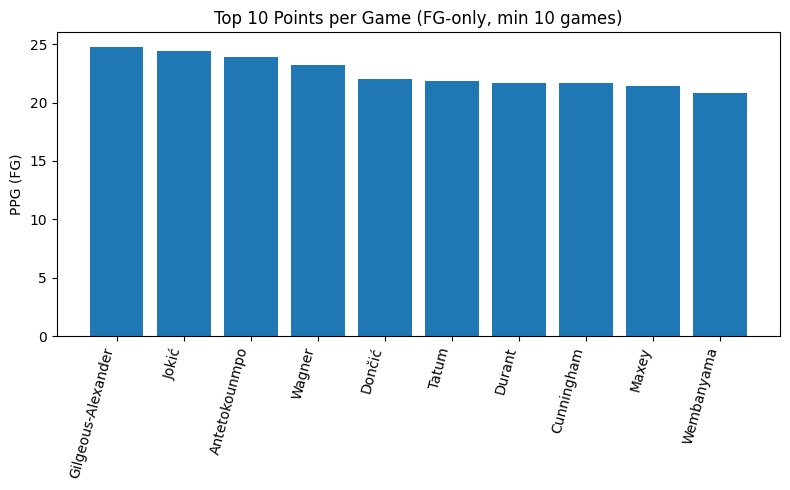

In [15]:
# === 12) Top 10 Points per Game Players (FG-only, min 10 games) ===
need = {'name','espn_game_id','fg_points'}
if need.issubset(shots.columns):
    pg = (shots.groupby(['name','espn_game_id'])
                .agg(points=('fg_points','sum'))
                .reset_index())

    ppg = (pg.groupby('name')
             .agg(ppg=('points','mean'), games=('espn_game_id','nunique'))
             .reset_index()
             .query('games >= 10')
             .sort_values('ppg', ascending=False)
             .head(10))

    print(ppg)
    fig = plt.figure(figsize=(8,5))
    plt.bar(ppg['name'], ppg['ppg'])
    plt.title("Top 10 Points per Game (FG-only, min 10 games)")
    plt.ylabel("PPG (FG)")
    plt.xticks(rotation=75, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Need name, espn_game_id, fg_points.")


## 13) Player Scatter — eFG% (x) vs Attempts (y), labeled (min 1000 attempts)

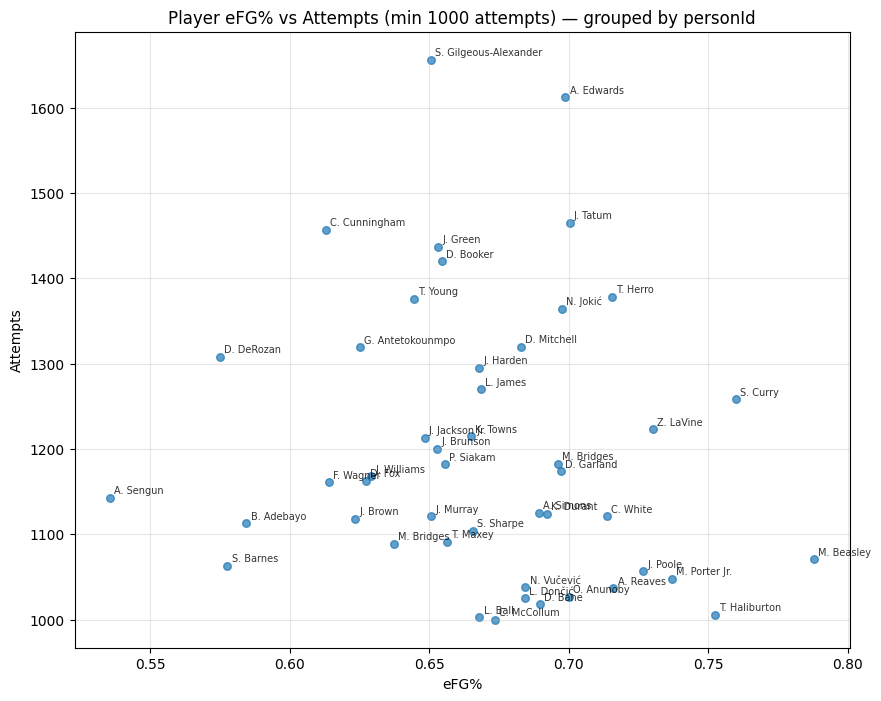

In [16]:
# === 13) Player eFG% vs Attempts (min 1000) — personId & playerNameI ===
need = {'personId','playerNameI','shot_made_flag','shotValue'}
if need.issubset(shots.columns):
    ps = (shots.groupby(['personId','playerNameI'])
                .agg(attempts=('shot_made_flag','size'),
                     makes=('shot_made_flag','sum'),
                     threes=('shotValue', lambda x: (x == 3).sum()))
                .reset_index())

    ps['efg_pct'] = (ps['makes'] + 0.5*ps['threes']) / ps['attempts']
    ps = ps.query('attempts >= 1000')

    fig = plt.figure(figsize=(10,8))
    plt.scatter(ps['efg_pct'], ps['attempts'], s=30, alpha=0.7)
    for _, r in ps.iterrows():
        plt.annotate(r['playerNameI'], (r['efg_pct'], r['attempts']),
                     xytext=(3,3), textcoords='offset points', fontsize=7, alpha=0.8)
    plt.title("Player eFG% vs Attempts (min 1000 attempts) — grouped by personId")
    plt.xlabel("eFG%"); plt.ylabel("Attempts")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Need personId, playerNameI, shot_made_flag, shotValue.")


## 14) Player Bad Shot % (x) vs Attempts (y), labeled (min 800 attempts)

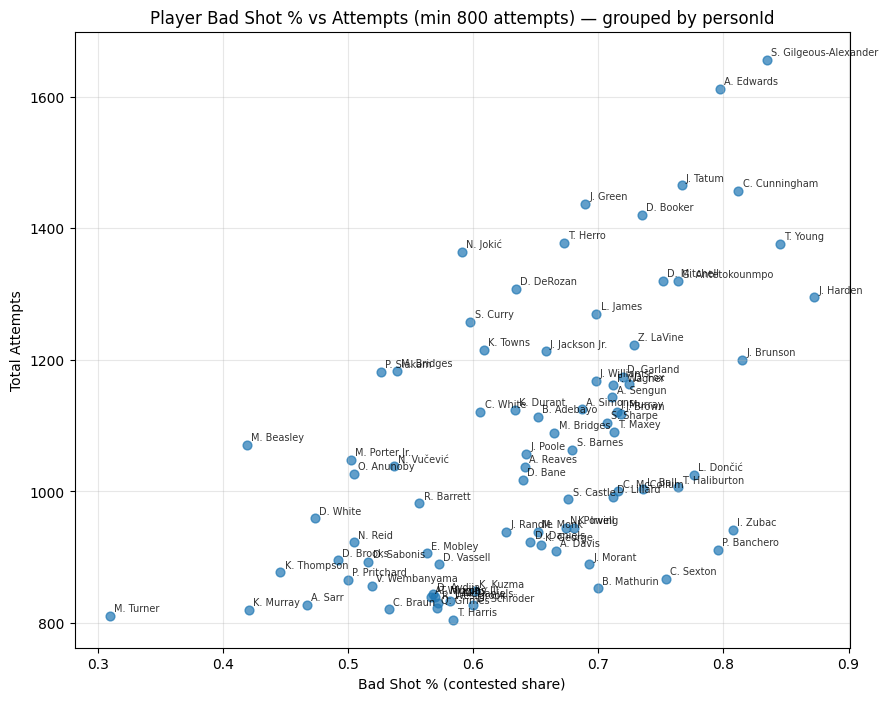

In [17]:
# === 14) Player "Bad Shot" % vs Attempts (min 800) — personId & playerNameI ===
label_words = ('contested', 'heavily', 'tightly')

if 'contest_score' in shots.columns or 'contest_label' in shots.columns:
    s = shots.copy()
    by_score = (s['contest_score'] >= 2) if 'contest_score' in s.columns else pd.Series(False, index=s.index)
    by_label = s['contest_label'].fillna('').str.lower().str.contains('|'.join(label_words)) if 'contest_label' in s.columns else pd.Series(False, index=s.index)
    s['is_contested'] = by_score | by_label

    if {'personId','playerNameI','is_contested','shot_made_flag'}.issubset(s.columns):
        bp = (s.groupby(['personId','playerNameI'])
                .agg(attempts=('shot_made_flag','size'),
                     bad_shot_pct=('is_contested','mean'))
                .reset_index())
        bp = bp.query('attempts >= 800')

        fig = plt.figure(figsize=(10,8))
        plt.scatter(bp['bad_shot_pct'], bp['attempts'], s=40, alpha=0.7)
        for _, r in bp.iterrows():
            plt.annotate(r['playerNameI'], (r['bad_shot_pct'], r['attempts']),
                         xytext=(3,3), textcoords='offset points', fontsize=7, alpha=0.8)
        plt.title("Player Bad Shot % vs Attempts (min 800 attempts) — grouped by personId")
        plt.xlabel("Bad Shot % (contested share)")
        plt.ylabel("Total Attempts")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("Need personId, playerNameI, is_contested, shot_made_flag.")
else:
    print("No 'contest_score' or 'contest_label'; skipping bad shot % analysis.")
